<a href="https://colab.research.google.com/github/umair594/Remote-internship_DS_CodeAlpha/blob/main/Car%20Price%20Prediction%20with%20Machine%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Car Price Prediction with Machine Learning**

# **Step 1: Problem Understanding**

**You want to predict the price of a car based on features like:**

Brand (company reputation / goodwill)

Horsepower

Mileage

Engine size

Fuel type

Transmission

Age of car

**This is a supervised learning regression problem because:**

Input = features

Output = continuous value (price)

# **Step 2: Import Libraries**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Step 3: Load Dataset**

**You can use datasets like:**

CarDekho dataset

Kaggle car price dataset

In [31]:
df = pd.read_csv("car data.csv")
print(df.head())
print(df.info())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  3

# **Step 4: Data Preprocessing**

**Handle Missing Values**

In [32]:
df = df.dropna()

**Convert Categorical Data → Numerical**

In [35]:
df.rename(columns={'Fuel_Type': 'fuel', 'Selling_type': 'seller_type'}, inplace=True)
print("Columns renamed:", df.columns)

Columns renamed: Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'fuel', 'seller_type', 'Transmission', 'Owner'],
      dtype='object')


Now we can convert the categorical data using the new column names.

In [34]:
le = LabelEncoder()

df['Fuel_Type'] = le.fit_transform(df['Fuel_Type'])
df['Selling_type'] = le.fit_transform(df['Selling_type'])
df['Transmission'] = le.fit_transform(df['Transmission'])

In [36]:
print(df.head())
print(df.info())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms  fuel  seller_type  \
0     ritz  2014           3.35           5.59       27000     2            0   
1      sx4  2013           4.75           9.54       43000     1            0   
2     ciaz  2017           7.25           9.85        6900     2            0   
3  wagon r  2011           2.85           4.15        5200     2            0   
4    swift  2014           4.60           6.87       42450     1            0   

   Transmission  Owner  
0             1      0  
1             1      0  
2             1      0  
3             1      0  
4             1      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    flo

**Feature Engineering (Create New Features)**

Example: Car Age

In [39]:
df['car_age'] = 2025 - df['Year']
df.drop(['Year'], axis=1, inplace=True)

# **Step 5: Exploratory Data Analysis (EDA)**

**Correlation Heatmap**

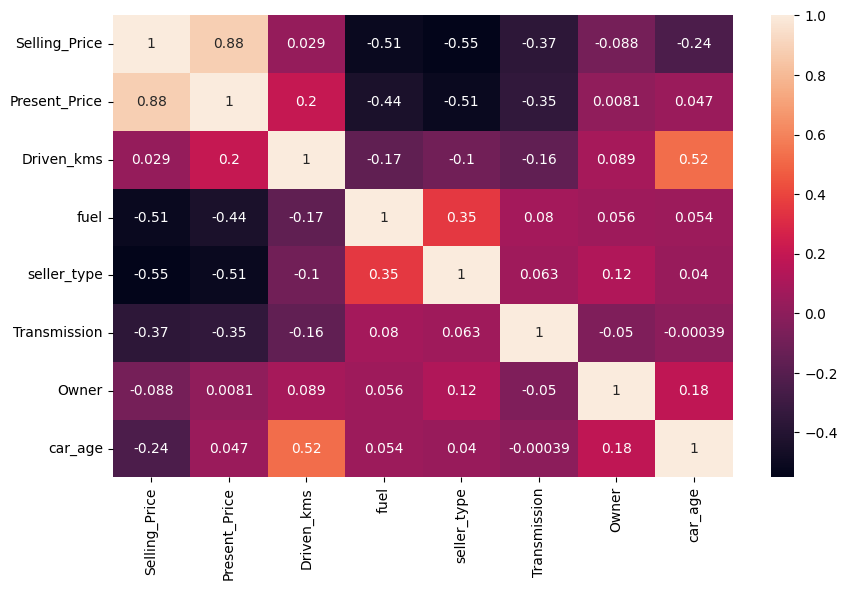

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop('Car_Name', axis=1).corr(), annot=True)
plt.show()

**Price Distribution**

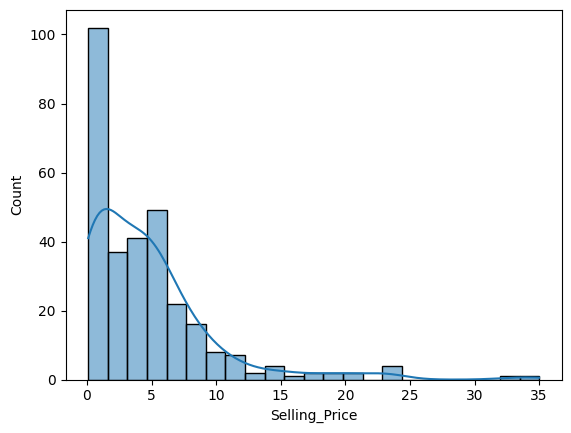

In [43]:
sns.histplot(df['Selling_Price'], kde=True)
plt.show()

**Helps understand**:

Feature importance

Outliers

Data patterns

# **Step 6: Define Features & Target**

In [45]:
X = df.drop(['Selling_Price'], axis=1)
y = df['Selling_Price']

# **Step 7: Train-Test Split**

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Step 8: Feature Scaling**

In [49]:
scaler = StandardScaler()

X_train = X_train.drop('Car_Name', axis=1)
X_test = X_test.drop('Car_Name', axis=1)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Step 9: Train Model**

**Linear Regression**

In [50]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# **Step 10: Make Predictions**

In [51]:
y_pred = model.predict(X_test)

# **Step 11: Model Evaluation**

In [52]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.221932362175391
MSE: 3.531579888968662
RMSE: 1.8792498207978263
R2 Score: 0.8466902419663817


**Interpretation:**

MAE → Average prediction error

RMSE → Penalizes large errors

R² Score → Accuracy (closer to 1 = better)

# **Step 12: Visualization of Results**

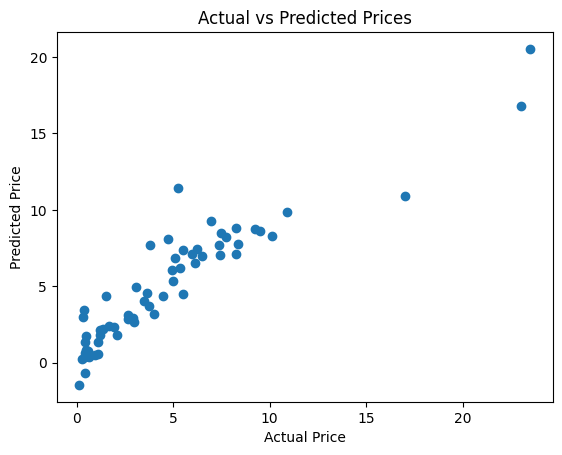

In [53]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

# **Step 13: Improve Model (Optional but Recommended)**

In [54]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("R2 Score (RF):", r2_score(y_test, y_pred_rf))

R2 Score (RF): 0.9639936016643915


**Usually performs better than Linear Regression.**

# **Real-World Applications**

**This type of model is used in:**

Car resale platforms (like OLX, PakWheels)

Insurance price estimation

Fleet valuation systems

Online marketplaces

# **Final Project Description (What You Learned)**

**Here’s a polished description you can submit:**

# **Project Description: Car Price Prediction using Machine Learning**

In this project, I developed a machine learning model to predict car prices based on various features such as brand value, horsepower, mileage, fuel type, and transmission. The goal was to understand how real-world pricing systems work using data-driven approaches.

I began by collecting and loading a dataset containing car attributes. I performed data preprocessing, including handling missing values and converting categorical variables into numerical formats using encoding techniques. I also engineered new features, such as car age, to improve model performance.

Next, I conducted exploratory data analysis (EDA) to identify patterns and relationships between features and the target variable. Using visualization tools like Matplotlib and Seaborn, I analyzed correlations and distributions.

I then split the dataset into training and testing sets and applied feature scaling to normalize the data. A Linear Regression model was trained to predict car prices, and its performance was evaluated using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

To improve accuracy, I also experimented with advanced models like Random Forest Regression, which provided better predictions.

**Through this project, I gained hands-on experience in:**

Data preprocessing and cleaning
Feature engineering
Model training and evaluation
Regression techniques in machine learning
Real-world application of predictive analytics

This project helped me understand how machine learning can be used in practical scenarios like price prediction systems in online marketplaces and automotive industries.